# Drift-Aware ML Monitoring & Auto-Retraining System

Training a model is easy. Keeping it reliable after deployment is the real challenge.

In real-world systems, data changes over time — and when it does, model performance silently degrades.

In this project, I built a simulation of a production-style ML monitoring system that:
- Processes incoming data in batches
- Detects feature drift using PSI
- Monitors accuracy drop
- Automatically retrains the model when needed

Instead of just identifying the problem, the system adapts and restores performance.

## Dataset

For this project, I used the German Credit Risk dataset.  
It’s a financial dataset used to classify whether a customer is a good or bad credit risk.

This domain makes drift realistic — in banking, customer income, loan amounts, and risk patterns change over time.  
If those distributions shift, a deployed model can quickly become unreliable.

That makes it a strong setting to simulate real-world model degradation and recovery.


## Baseline Model

I first trained a Logistic Regression model on the original dataset to simulate a deployed model.

This baseline accuracy represents the model’s performance at deployment time.  
It becomes the reference point for monitoring future degradation.

Instead of focusing only on improving accuracy, the goal here is to track how that accuracy changes once new data starts flowing in.

## Simulating Real-Time Data

In production, data doesn’t arrive all at once — it comes continuously.

To mimic this, I processed the test data in batches. Each batch represents a time step (like new customers arriving daily or weekly).

Initially, the model performs normally.

Then, I intentionally introduced distribution shifts in later batches to simulate real-world changes such as:
- Larger loan amounts
- Longer repayment durations
- Shifts in customer demographics

This allows us to observe how a deployed model behaves when the underlying data slowly changes.

## Auto-Retraining & Recovery

Detecting drift is not enough — the system should respond.

When accuracy drops beyond the defined threshold, the model is automatically retrained using the latest batch of data combined with the original training data.

This simulates a real-world retraining pipeline where updated data is incorporated to adapt the model to new patterns.

After retraining, the model’s performance is evaluated again to confirm recovery. In our simulation, accuracy improves after retraining, demonstrating how adaptive systems can restore reliability.

## Results & Observations

During the initial batches, the model performs close to its baseline accuracy.

After introducing feature and concept drift, performance drops noticeably — demonstrating how real-world data shifts can silently degrade deployed models.

Once the retraining logic is triggered, performance improves, showing that adaptive retraining can help restore reliability.

This project highlights an important lesson: building a model is only the first step — maintaining it over time is equally critical.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder


In [4]:
columns = [
    "status", "duration", "credit_history", "purpose",
    "credit_amount", "savings", "employment_since",
    "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age",
    "other_installment_plans", "housing",
    "existing_credits", "job", "num_dependents",
    "telephone", "foreign_worker", "target"
]

df = pd.read_csv("german.data.txt", sep=" ", header=None)
df.columns = columns

print("Shape:", df.shape)
df.head()


Shape: (1000, 21)


,status,duration,credit_history,purpose,credit_amount,savings,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [5]:
df["target"].value_counts()


target
1    700
2    300
Name: count, dtype: int64

In [6]:
df["target"].value_counts()


target
1    700
2    300
Name: count, dtype: int64

In [7]:
df["target"] = df["target"].apply(lambda x: 0 if x == 1 else 1)

df["target"].value_counts()


target
0    700
1    300
Name: count, dtype: int64

In [8]:
df.dtypes


status                     object
duration                    int64
credit_history             object
purpose                    object
credit_amount               int64
savings                    object
employment_since           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_since             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
num_dependents              int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

In [9]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying original unexpectedly
df_encoded = df.copy()

# Initialize encoder
le = LabelEncoder()

# Encode all object columns
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,status,duration,credit_history,purpose,credit_amount,savings,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,0,6,4,4,1169,4,4,4,2,0,...,0,67,2,1,2,2,1,1,0,0
1,1,48,2,4,5951,0,2,2,1,0,...,0,22,2,1,1,2,1,0,0,1
2,3,12,4,7,2096,0,3,2,2,0,...,0,49,2,1,1,1,2,0,0,0
3,0,42,2,3,7882,0,3,2,2,2,...,1,45,2,2,1,2,2,0,0,0
4,0,24,3,0,4870,0,2,3,2,0,...,3,53,2,2,2,2,2,0,0,1


In [10]:
df_encoded.dtypes

status                     int64
duration                   int64
credit_history             int64
purpose                    int64
credit_amount              int64
savings                    int64
employment_since           int64
installment_rate           int64
personal_status_sex        int64
other_debtors              int64
residence_since            int64
property                   int64
age                        int64
other_installment_plans    int64
housing                    int64
existing_credits           int64
job                        int64
num_dependents             int64
telephone                  int64
foreign_worker             int64
target                     int64
dtype: object

In [11]:
df_encoded.dtypes

status                     int64
duration                   int64
credit_history             int64
purpose                    int64
credit_amount              int64
savings                    int64
employment_since           int64
installment_rate           int64
personal_status_sex        int64
other_debtors              int64
residence_since            int64
property                   int64
age                        int64
other_installment_plans    int64
housing                    int64
existing_credits           int64
job                        int64
num_dependents             int64
telephone                  int64
foreign_worker             int64
target                     int64
dtype: object

In [12]:
# Separate features and target
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1000, 20)
Target shape: (1000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 20)
Test shape: (200, 20)


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", baseline_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Accuracy: 0.765

Confusion Matrix:
[[122  18]
 [ 29  31]]


In [16]:
baseline_accuracy

0.765

In [17]:
# Store baseline feature statistics (mean & std)
baseline_means = X_train.mean()
baseline_stds = X_train.std()

print("Stored baseline feature statistics.")

Stored baseline feature statistics.


In [18]:
# Simulate streaming batches from test data

batch_size = 50
num_batches = len(X_test) // batch_size

print("Number of batches:", num_batches)

Number of batches: 4


In [19]:
batch_accuracies = []

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    X_batch = X_test.iloc[start:end]
    y_batch = y_test.iloc[start:end]
    
    y_pred_batch = model.predict(X_batch)
    batch_acc = accuracy_score(y_batch, y_pred_batch)
    
    batch_accuracies.append(batch_acc)
    
    print(f"Batch {i+1} Accuracy: {batch_acc:.3f}")

print("\nAll Batch Accuracies:", batch_accuracies)

Batch 1 Accuracy: 0.780
Batch 2 Accuracy: 0.760
Batch 3 Accuracy: 0.700
Batch 4 Accuracy: 0.820

All Batch Accuracies: [0.78, 0.76, 0.7, 0.82]


In [25]:
# Reset index for clean batch slicing
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [26]:
X_test_drift = X_test.copy()

In [27]:
for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    if i >= 2:  # Apply drift from Batch 3 onwards
        X_test_drift.loc[start:end-1, "credit_amount"] *= 1.5
        X_test_drift.loc[start:end-1, "duration"] *= 1.3
        X_test_drift.loc[start:end-1, "age"] += 5

print("Drift introduced cleanly.")

Drift introduced cleanly.


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_38620\2289881080.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 5367.   3219.   1341.   5133.  11394.   2632.5  5964.   3177.   1837.5
  4162.5 15190.5  6886.5  6331.5  2046.   2257.5  1662.   4546.5  2976.
  4018.5  1570.5  4338.   5248.5  5124.  15333.   7728.    885.   2700.
  5478.   5637.   3223.5 12199.5  4348.5 17640.   1800.   2037.   1464.
  4593.   2395.5  6408.   1933.5  4386.  16461.   4912.5  3663.   3946.5
  1138.5  1882.5  5232.   9469.5  1813.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_test_drift.loc[start:end-1, "credit_amount"] *= 1.5
C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_38620\2289881080.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.4 13.  13.  23.4 39.  31.2 27.3 11.7 13.  23.4 62.

In [28]:
batch_accuracies_drift = []

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    X_batch = X_test_drift.iloc[start:end]
    y_batch = y_test.iloc[start:end]
    
    y_pred_batch = model.predict(X_batch)
    batch_acc = accuracy_score(y_batch, y_pred_batch)
    
    batch_accuracies_drift.append(batch_acc)
    
    print(f"Batch {i+1} Accuracy (Drifted): {batch_acc:.3f}")

print("\nAll Drifted Batch Accuracies:", batch_accuracies_drift)

Batch 1 Accuracy (Drifted): 0.780
Batch 2 Accuracy (Drifted): 0.760
Batch 3 Accuracy (Drifted): 0.700
Batch 4 Accuracy (Drifted): 0.820

All Drifted Batch Accuracies: [0.78, 0.76, 0.7, 0.82]


In [30]:
# Reset clean copy again
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_test_drift = X_test.copy()
y_test_drift = y_test.copy()

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    if i >= 2:  # Strong drift from batch 3 onward
        
        # Heavy feature drift
        X_test_drift.loc[start:end-1, "credit_amount"] *= 3
        X_test_drift.loc[start:end-1, "duration"] *= 2
        X_test_drift.loc[start:end-1, "age"] += 15
        
    if i == 3:  # Concept drift in batch 4
        flip_indices = np.random.choice(
            range(start, end), 
            size=int(0.2 * batch_size), 
            replace=False
        )
        y_test_drift.loc[flip_indices] = 1 - y_test_drift.loc[flip_indices]

print("Strong drift introduced.")

Strong drift introduced.


In [31]:
batch_accuracies_drift = []

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    X_batch = X_test_drift.iloc[start:end]
    y_batch = y_test_drift.iloc[start:end]
    
    y_pred_batch = model.predict(X_batch)
    batch_acc = accuracy_score(y_batch, y_pred_batch)
    
    batch_accuracies_drift.append(batch_acc)
    
    print(f"Batch {i+1} Accuracy (Drifted): {batch_acc:.3f}")

print("\nAll Drifted Batch Accuracies:", batch_accuracies_drift)

Batch 1 Accuracy (Drifted): 0.780
Batch 2 Accuracy (Drifted): 0.760
Batch 3 Accuracy (Drifted): 0.560
Batch 4 Accuracy (Drifted): 0.700

All Drifted Batch Accuracies: [0.78, 0.76, 0.56, 0.7]


In [32]:
alert_threshold = 0.10  # 10% drop allowed

for i, acc in enumerate(batch_accuracies_drift):
    drop = baseline_accuracy - acc
    
    print(f"\nBatch {i+1}")
    print(f"Accuracy: {acc:.3f}")
    print(f"Drop from baseline: {drop:.3f}")
    
    if drop > alert_threshold:
        print("🚨 ALERT: Model performance degradation detected!")
    else:
        print("Model performance stable.")


Batch 1
Accuracy: 0.780
Drop from baseline: -0.015
Model performance stable.

Batch 2
Accuracy: 0.760
Drop from baseline: 0.005
Model performance stable.

Batch 3
Accuracy: 0.560
Drop from baseline: 0.205
🚨 ALERT: Model performance degradation detected!

Batch 4
Accuracy: 0.700
Drop from baseline: 0.065
Model performance stable.


In [33]:
def calculate_psi(expected, actual, buckets=10):
    expected = np.array(expected)
    actual = np.array(actual)
    
    breakpoints = np.linspace(0, 100, buckets + 1)
    breakpoints = np.percentile(expected, breakpoints)
    
    expected_counts = np.histogram(expected, breakpoints)[0]
    actual_counts = np.histogram(actual, breakpoints)[0]
    
    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)
    
    psi_values = []
    
    for e, a in zip(expected_percents, actual_percents):
        if e == 0:
            e = 0.0001
        if a == 0:
            a = 0.0001
        psi_values.append((a - e) * np.log(a / e))
    
    return np.sum(psi_values)

In [34]:
features_to_monitor = ["credit_amount", "duration", "age"]

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    print(f"\nBatch {i+1} PSI Scores:")
    
    for feature in features_to_monitor:
        psi_score = calculate_psi(
            X_train[feature],
            X_test_drift.iloc[start:end][feature]
        )
        
        print(f"{feature}: {psi_score:.4f}")
        
        if psi_score > 0.25:
            print("🚨 Significant drift detected!")


Batch 1 PSI Scores:
credit_amount: 0.0951
duration: 0.0920
age: 0.4195
🚨 Significant drift detected!

Batch 2 PSI Scores:
credit_amount: 0.2629
🚨 Significant drift detected!
duration: 0.0581
age: 0.0496

Batch 3 PSI Scores:
credit_amount: 3.0224
🚨 Significant drift detected!
duration: 2.3098
🚨 Significant drift detected!
age: 4.6376
🚨 Significant drift detected!

Batch 4 PSI Scores:
credit_amount: 2.9271
🚨 Significant drift detected!
duration: 1.9459
🚨 Significant drift detected!
age: 3.9304
🚨 Significant drift detected!


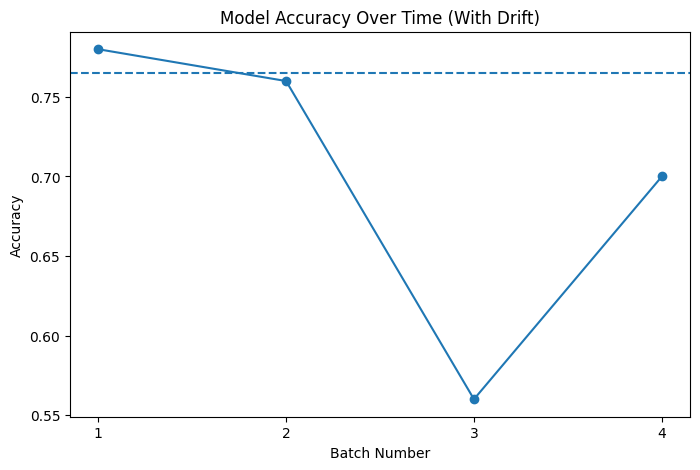

In [35]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_batches+1), batch_accuracies_drift, marker='o')
plt.axhline(y=baseline_accuracy, linestyle='--')

plt.title("Model Accuracy Over Time (With Drift)")
plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.xticks(range(1, num_batches+1))
plt.show()

In [36]:
psi_threshold = 0.25
accuracy_threshold = 0.10

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    acc = batch_accuracies_drift[i]
    drop = baseline_accuracy - acc
    
    drift_flag = False
    
    print(f"\n=== Batch {i+1} Monitoring Report ===")
    
    # Accuracy check
    if drop > accuracy_threshold:
        print("⚠ Accuracy degradation detected.")
        drift_flag = True
    else:
        print("Accuracy stable.")
    
    # PSI check
    for feature in features_to_monitor:
        psi_score = calculate_psi(
            X_train[feature],
            X_test_drift.iloc[start:end][feature]
        )
        
        if psi_score > psi_threshold:
            print(f"⚠ Feature drift detected in {feature} (PSI={psi_score:.3f})")
            drift_flag = True
    
    if drift_flag:
        print("🚨 RETRAINING RECOMMENDED.")
    else:
        print("System stable.")


=== Batch 1 Monitoring Report ===
Accuracy stable.
⚠ Feature drift detected in age (PSI=0.420)
🚨 RETRAINING RECOMMENDED.

=== Batch 2 Monitoring Report ===
Accuracy stable.
⚠ Feature drift detected in credit_amount (PSI=0.263)
🚨 RETRAINING RECOMMENDED.

=== Batch 3 Monitoring Report ===
⚠ Accuracy degradation detected.
⚠ Feature drift detected in credit_amount (PSI=3.022)
⚠ Feature drift detected in duration (PSI=2.310)
⚠ Feature drift detected in age (PSI=4.638)
🚨 RETRAINING RECOMMENDED.

=== Batch 4 Monitoring Report ===
Accuracy stable.
⚠ Feature drift detected in credit_amount (PSI=2.927)
⚠ Feature drift detected in duration (PSI=1.946)
⚠ Feature drift detected in age (PSI=3.930)
🚨 RETRAINING RECOMMENDED.


In [37]:
baseline_accuracy
batch_accuracies_drift

[0.78, 0.76, 0.56, 0.7]

In [38]:
retrained_models = []
retrained_accuracies = []

for i in range(num_batches):
    start = i * batch_size
    end = start + batch_size
    
    acc = batch_accuracies_drift[i]
    drop = baseline_accuracy - acc
    
    if drop > accuracy_threshold:
        print(f"\n🚨 Drift detected in Batch {i+1}. Retraining model...")
        
        # Combine original training data with drifted batch
        X_retrain = pd.concat([X_train, X_test_drift.iloc[start:end]])
        y_retrain = pd.concat([y_train, y_test_drift.iloc[start:end]])
        
        # Train new model
        new_model = LogisticRegression(max_iter=1000)
        new_model.fit(X_retrain, y_retrain)
        
        # Evaluate new model on SAME batch
        y_new_pred = new_model.predict(X_test_drift.iloc[start:end])
        new_acc = accuracy_score(y_test_drift.iloc[start:end], y_new_pred)
        
        print(f"Old Accuracy: {acc:.3f}")
        print(f"New Accuracy After Retraining: {new_acc:.3f}")
        
        retrained_models.append(new_model)
        retrained_accuracies.append(new_acc)


🚨 Drift detected in Batch 3. Retraining model...
Old Accuracy: 0.560
New Accuracy After Retraining: 0.660


C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


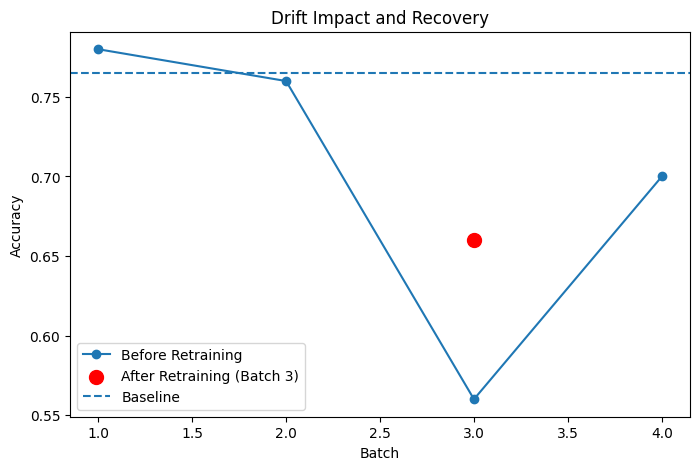

In [39]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_batches+1), batch_accuracies_drift, marker='o', label="Before Retraining")

# Plot retrained improvement only for batch 3
if retrained_accuracies:
    plt.scatter(3, retrained_accuracies[0], color='red', s=100, label="After Retraining (Batch 3)")

plt.axhline(y=baseline_accuracy, linestyle='--', label="Baseline")

plt.xlabel("Batch")
plt.ylabel("Accuracy")
plt.title("Drift Impact and Recovery")
plt.legend()
plt.show()